# 🧠 Entrenamiento PPO con TF-Agents en el entorno Pendulum-v1 (Gymnasium)
Este notebook implementa un agente PPO (Proximal Policy Optimization) utilizando la librería `tf_agents` y el entorno `Pendulum-v1` de `Gymnasium`.

Incluye:
- Entrenamiento eficiente.
- Generación de video del agente entrenado vs aleatorio.
- Visualización de recompensa a lo largo del tiempo.


In [1]:
!pip install tf-agents[reverb] --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.1 which is incompatible.


In [12]:
# ⚠️ Instalar dependencias (reiniciar kernel tras instalar si ocurre error)
!pip install gym-super-mario-bros==7.4.0 nes-py==8.2.1 gymnasium==0.28.1 pygame --quiet


KeyboardInterrupt: 

In [3]:
import gymnasium as gym
env = gym.make("Pendulum-v1", render_mode="rgb_array")


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [6]:
from tf_agents.environments import suite_gym
from tf_agents.environments import tf_py_environment

train_env = tf_py_environment.TFPyEnvironment(suite_gym.load("Pendulum-v1"))


In [7]:
# ✅ Crear entorno limpio solo para visualización (rendering por imageio)
import gymnasium as gym
eval_env = gym.make("Pendulum-v1", render_mode="rgb_array")


In [8]:
import tensorflow as tf
from tf_agents.agents.ppo import ppo_clip_agent
from tf_agents.networks.actor_distribution_network import ActorDistributionNetwork
from tf_agents.networks.value_network import ValueNetwork
from tf_agents.trajectories import time_step as ts
from tf_agents.utils import common

actor_net = ActorDistributionNetwork(train_env.observation_spec(), train_env.action_spec())
value_net = ValueNetwork(train_env.observation_spec())

global_step = tf.compat.v1.train.get_or_create_global_step()

agent = ppo_clip_agent.PPOClipAgent(
    train_env.time_step_spec(),
    train_env.action_spec(),
    actor_net=actor_net,
    value_net=value_net,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    train_step_counter=global_step
)
agent.initialize()


Instructions for updating:
Use `as_dataset(..., single_deterministic_pass=True)` instead.


🔁 Iteración 10/100 - Recompensa promedio: -1303.35
🔁 Iteración 20/100 - Recompensa promedio: -1371.58
🔁 Iteración 30/100 - Recompensa promedio: -1325.72
🔁 Iteración 40/100 - Recompensa promedio: -1325.92
🔁 Iteración 50/100 - Recompensa promedio: -1277.28
🔁 Iteración 60/100 - Recompensa promedio: -1115.96
🔁 Iteración 70/100 - Recompensa promedio: -1037.84
🔁 Iteración 80/100 - Recompensa promedio: -1458.47
🔁 Iteración 90/100 - Recompensa promedio: -1455.40
🔁 Iteración 100/100 - Recompensa promedio: -1433.55
💾 Checkpoint guardado en iteración 100


✅ Política final guardada en 'ppo_policy'


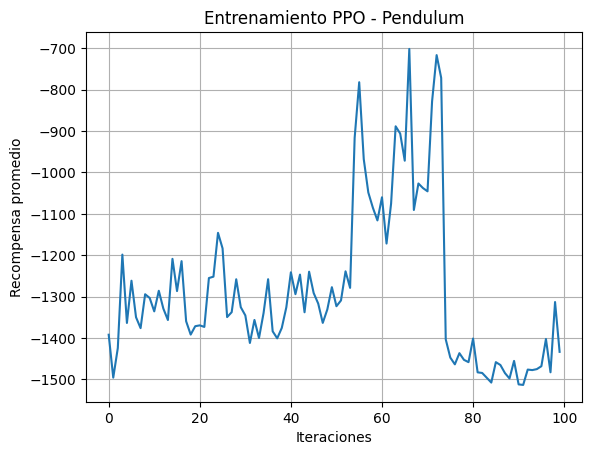

In [9]:
from tf_agents.drivers.dynamic_step_driver import DynamicStepDriver
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.metrics import tf_metrics
from tf_agents.policies import random_tf_policy
from tf_agents.trajectories import trajectory
from tf_agents.utils import common
from tf_agents.policies import policy_saver

import matplotlib.pyplot as plt
import os

# ⚙️ Ajustes del entrenamiento
num_iterations = 100
collect_steps_per_iteration = 2048  # mejor para PPO
checkpoint_interval = 100

# 📦 Replay Buffer
replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=agent.collect_data_spec,
    batch_size=train_env.batch_size,
    max_length=collect_steps_per_iteration * 2
)

# 📊 Métricas
train_metrics = [
    tf_metrics.NumberOfEpisodes(),
    tf_metrics.EnvironmentSteps(),
    tf_metrics.AverageReturnMetric(buffer_size=10),
    tf_metrics.AverageEpisodeLengthMetric(),
]

# 🔁 Driver
collect_driver = DynamicStepDriver(
    env=train_env,
    policy=agent.collect_policy,
    observers=[replay_buffer.add_batch] + train_metrics,
    num_steps=collect_steps_per_iteration
)

# 💾 Checkpoints
checkpoint_dir = 'ppo_checkpoints'
checkpoint = tf.train.Checkpoint(agent=agent)
checkpoint_manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=5)

# 💾 Saver para exportar política final
policy_dir = "ppo_policy"
tf_policy_saver = policy_saver.PolicySaver(agent.policy)

# 🏁 Entrenamiento principal
reward_history = []

agent.initialize()

for iteration in range(num_iterations):
    try:
        collect_driver.run()
    except Exception as e:
        print(f"⚠️ Error al recolectar datos: {e}. Reiniciando entorno.")
        train_env.reset()
        continue

    experience = replay_buffer.gather_all()
    train_loss = agent.train(experience)
    replay_buffer.clear()

    avg_return = train_metrics[2].result().numpy()
    reward_history.append(avg_return)

    if (iteration + 1) % 10 == 0:
        print(f"🔁 Iteración {iteration+1}/{num_iterations} - Recompensa promedio: {avg_return:.2f}")

    if (iteration + 1) % checkpoint_interval == 0:
        checkpoint_manager.save()
        print(f"💾 Checkpoint guardado en iteración {iteration+1}")

# 💾 Guardar política entrenada
tf_policy_saver.save(policy_dir)
print(f"✅ Política final guardada en '{policy_dir}'")

# 📈 Graficar progreso
plt.plot(reward_history)
plt.xlabel("Iteraciones")
plt.ylabel("Recompensa promedio")
plt.title("Entrenamiento PPO - Pendulum")
plt.grid(True)
plt.show()



In [13]:
def generate_video(policy, environment, filename="ppo_agent_pendulum.mp4", num_episodes=1, max_frames=200):
    import imageio
    import numpy as np
    from tf_agents.trajectories import time_step as ts

    frames = []
    env = environment.envs[0] if hasattr(environment, 'envs') else environment
    is_random_policy = "RandomTFPolicy" in policy.__class__.__name__

    for _ in range(num_episodes):
        obs, _ = env.reset()
        frames.append(env.render())

        reward = 0.0
        done = False
        steps = 0

        # Empaquetar la observación correctamente según el tipo de política
        if is_random_policy:
            obs_tensor = tf.convert_to_tensor(np.expand_dims(obs, axis=0), dtype=tf.float32)
            time_step_tf = ts.restart(observation=obs_tensor)
        else:
            time_step_tf = ts.transition(np.expand_dims(obs, axis=0).astype(np.float32), reward=reward)

        while not done and steps < max_frames:
            action = policy.action(time_step_tf).action.numpy()[0]
            obs, reward, terminated, truncated, _ = env.step(action)
            frames.append(env.render())
            done = terminated or truncated
            steps += 1

            if is_random_policy:
                obs_tensor = tf.convert_to_tensor(np.expand_dims(obs, axis=0), dtype=tf.float32)
                time_step_tf = ts.transition(observation=obs_tensor, reward=reward)
            else:
                time_step_tf = ts.transition(np.expand_dims(obs, axis=0).astype(np.float32), reward=reward)

    with imageio.get_writer(filename, fps=30, macro_block_size=None) as video:
        for frame in frames:
            video.append_data(np.array(frame))

    print(f"🎥 Video guardado como: {filename}")
    return filename
